In [1]:
!python3 borough_complaints.py -i ~/data/311_2024.csv -s 2024-01-01 -e 2024-02-29 -o jan_feb.csv
!python3 borough_complaints.py -i ~/data/311_2024.csv -s 2024-06-01 -e 2024-07-31 -o jun_jul.csv
!wc -l jan_feb.csv jun_jul.csv

  789 jan_feb.csv
  819 jun_jul.csv
 1608 total


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

jan_feb = pd.read_csv("jan_feb.csv")
jun_jul = pd.read_csv("jun_jul.csv")

jf_totals = jan_feb.groupby("complaint type")["count"].sum().sort_values(ascending=False)
top_type = jf_totals.index[0]
print("Most abundant complaint type, Jan-Feb 2024:", top_type)
jf_totals.head(10)

Most abundant complaint type, Jan-Feb 2024: HEAT/HOT WATER


complaint type
HEAT/HOT WATER          81641
Illegal Parking         79916
Noise - Residential     43602
Blocked Driveway        28608
UNSANITARY CONDITION    19208
PLUMBING                12060
PAINT/PLASTER           11725
Abandoned Vehicle       11466
Street Condition        10874
WATER LEAK               9178
Name: count, dtype: int64

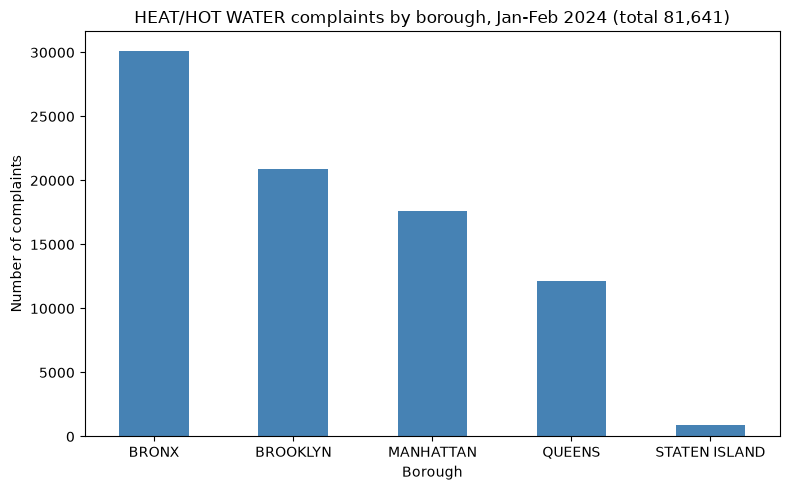

In [3]:
jf_top = jan_feb[jan_feb["complaint type"] == top_type].set_index("borough")["count"]

ax = jf_top.sort_values(ascending=False).plot.bar(figsize=(8, 5), color="steelblue")
ax.set_title(f"{top_type} complaints by borough, Jan-Feb 2024 (total {jf_top.sum():,})")
ax.set_xlabel("Borough")
ax.set_ylabel("Number of complaints")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("jan_feb_top_complaint.png")
plt.show()

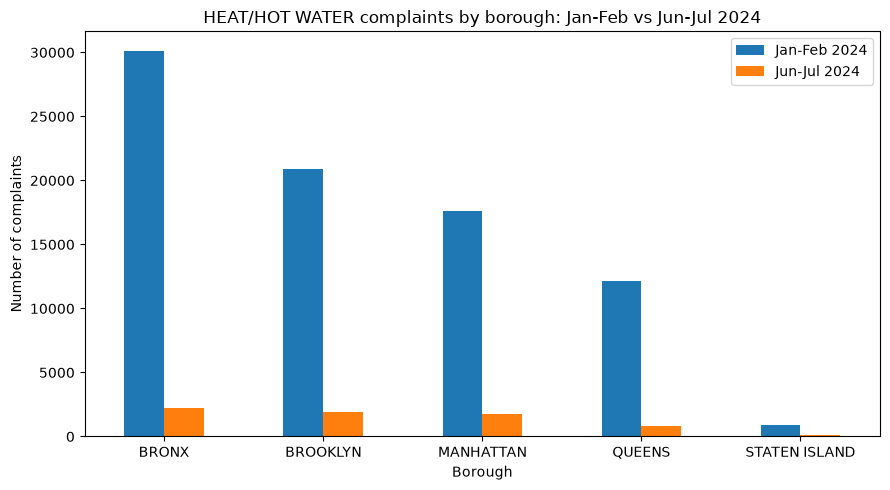

Totals: 81641 vs 6890


,Jan-Feb 2024,Jun-Jul 2024,change (%)
borough,,,
BRONX,30139,2227,-92.6
BROOKLYN,20915,1929,-90.8
MANHATTAN,17604,1778,-89.9
QUEENS,12117,835,-93.1
STATEN ISLAND,866,121,-86.0


In [4]:
jj_top = jun_jul[jun_jul["complaint type"] == top_type].set_index("borough")["count"]

compare = pd.DataFrame({"Jan-Feb 2024": jf_top, "Jun-Jul 2024": jj_top}).fillna(0).astype(int)
compare["change (%)"] = ((compare["Jun-Jul 2024"] - compare["Jan-Feb 2024"])
                         / compare["Jan-Feb 2024"] * 100).round(1)

ax = compare[["Jan-Feb 2024", "Jun-Jul 2024"]].plot.bar(figsize=(9, 5))
ax.set_title(f"{top_type} complaints by borough: Jan-Feb vs Jun-Jul 2024")
ax.set_xlabel("Borough")
ax.set_ylabel("Number of complaints")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("jan_feb_vs_jun_jul.png")
plt.show()

print("Totals:", compare["Jan-Feb 2024"].sum(), "vs", compare["Jun-Jul 2024"].sum())
compare

In [5]:
jj_totals = jun_jul.groupby("complaint type")["count"].sum().sort_values(ascending=False)
print("Rank of", top_type, "in Jun-Jul:", list(jj_totals.index).index(top_type) + 1)
jj_totals.head(10)

Rank of HEAT/HOT WATER in Jun-Jul: 25


complaint type
Illegal Parking            86240
Noise - Residential        58197
Noise - Street/Sidewalk    47320
Blocked Driveway           27193
Water System               21653
UNSANITARY CONDITION       21578
Street Condition           13273
Dirty Condition            12399
Abandoned Vehicle          12235
PLUMBING                   10912
Name: count, dtype: int64